In [30]:
import pandas as pd
import numpy as np

# 1. Carregar a base de dados do Lens
caminho_arquivo = '/content/drive/MyDrive/lens-export.csv'
try:
    df_patentes = pd.read_csv(caminho_arquivo)

    # Padronização de nomes de colunas do Lens
    col_resumo = 'Resumo'
    col_citacoes = 'Citado pela contagem de patentes'
    col_ano = 'Ano de Publicação'
    col_id = 'ID da lente'

    # Limpeza inicial e tratamento de tipos
    df_patentes = df_patentes.dropna(subset=[col_resumo]).copy()
    df_patentes[col_citacoes] = pd.to_numeric(df_patentes[col_citacoes], errors='coerce').fillna(0)
    df_patentes[col_ano] = pd.to_numeric(df_patentes[col_ano], errors='coerce')

    # 2. CÁLCULO DO CII (Impacto relativo ao ano)
    # Média de citações por ano
    medias_por_ano = df_patentes.groupby(col_ano)[col_citacoes].mean().reset_index()
    medias_por_ano.rename(columns={col_citacoes: 'media_do_ano'}, inplace=True)

    # Cruzamento de dados
    df_patentes = pd.merge(df_patentes, medias_por_ano, on=col_ano, how='left')

    # Cálculo final: (Citações da Patente / Média do seu Ano)
    df_patentes['cii_real'] = np.where(df_patentes['media_do_ano'] > 0,
                                       df_patentes[col_citacoes] / df_patentes['media_do_ano'],
                                       0.0)

    # 3. EXIBIÇÃO DOS RESULTADOS
    print(f"✅ Dados carregados com sucesso de: {caminho_arquivo}")
    colunas_final = [col_id, col_ano, col_citacoes, 'media_do_ano', 'cii_real']

    # Mostrar o 500 patentes com maior impacto (CII)
    display(df_patentes[colunas_final].sort_values(by='cii_real', ascending=False).head(500))
except FileNotFoundError:
    print(f"❌ Erro: O arquivo '{caminho_arquivo}' não foi encontrado. Verifique se o Google Drive está montado.")

✅ Dados carregados com sucesso de: /content/drive/MyDrive/lens-export.csv


,ID da lente,Ano de Publicação,Citado pela contagem de patentes,media_do_ano,cii_real
164,034-940-975-354-890,2000,1,0.024390,41.0
754,078-737-539-195-988,2006,2,0.054054,37.0
42,153-366-283-721-697,2011,1,0.027027,37.0
571,147-550-979-575-635,2017,1,0.031250,32.0
448,079-598-680-589-23X,2017,1,0.031250,32.0
...,...,...,...,...,...
39,121-777-679-031-022,2006,0,0.054054,0.0
40,128-716-549-903-692,2016,0,0.000000,0.0
41,137-956-813-641-898,2009,0,0.076923,0.0
43,166-437-729-335-086,2007,0,0.000000,0.0


/tmp/ipykernel_7828/185310412.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='cii_real', y=col_id, ax=ax2, palette='viridis')


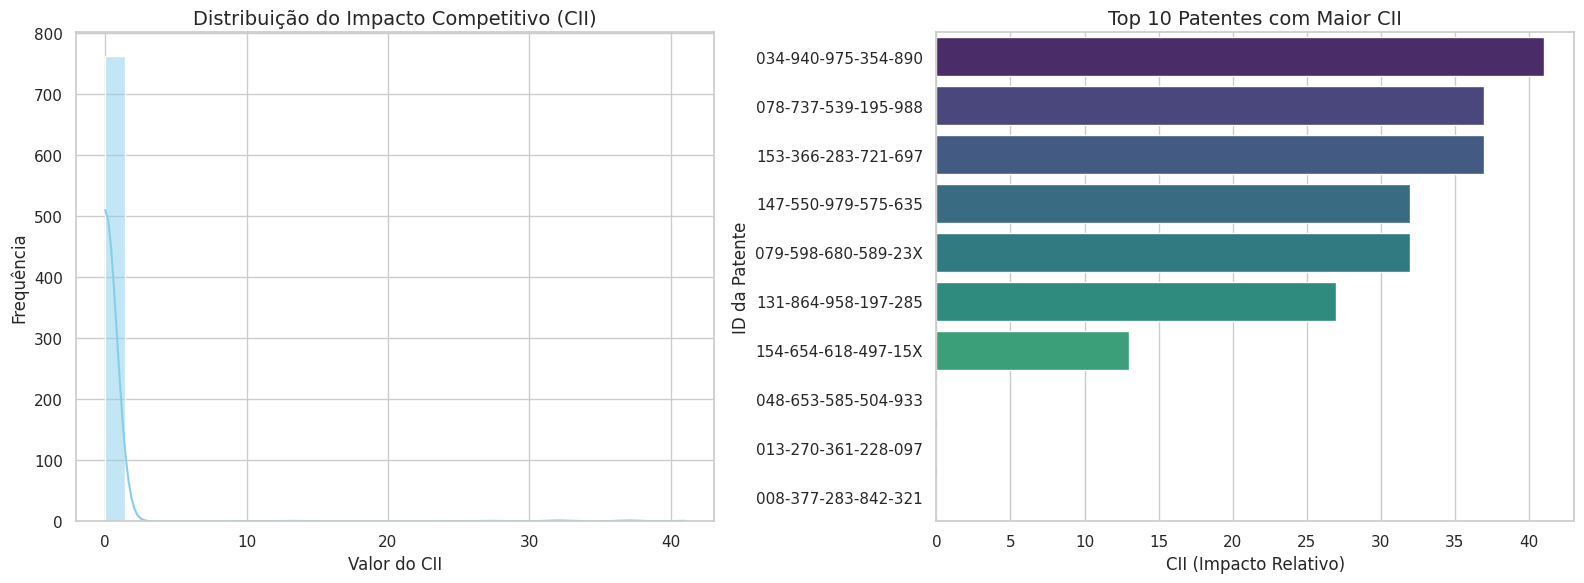

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Distribuição do CII
sns.histplot(df_patentes['cii_real'], bins=30, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribuição do Impacto Competitivo (CII)', fontsize=14)
ax1.set_xlabel('Valor do CII')
ax1.set_ylabel('Frequência')

# 2. Top 10 Patentes por Impacto
top_10 = df_patentes.sort_values(by='cii_real', ascending=False).head(10)
sns.barplot(data=top_10, x='cii_real', y=col_id, ax=ax2, palette='viridis')
ax2.set_title('Top 10 Patentes com Maior CII', fontsize=14)
ax2.set_xlabel('CII (Impacto Relativo)')
ax2.set_ylabel('ID da Patente')

plt.tight_layout()
plt.show()

### Análise dos Gráficos:
- **Distribuição do CII:** A maioria das patentes tende a ficar próxima de 1.0 (a média do seu ano). Valores muito acima de 1.0 indicam patentes disruptivas que receberam muito mais citações que seus pares.
- **Ranking:** O gráfico à direita destaca visualmente quais tecnologias no seu arquivo do Lens possuem a maior dominância técnica baseada em citações.

In [29]:
# Código para salvar os gráficos para o seu portfólio
import os

# Criar pasta para imagens se não existir
if not os.path.exists('visualizacoes'):
    os.makedirs('visualizacoes')

# Salvar o gráfico atual como imagem PNG para o GitHub
fig.savefig('visualizacoes/distribuicao_cii.png', dpi=300)
print("✅ Gráfico salvo na pasta 'visualizacoes/distribuicao_cii.png'. Baixe-o para seu repositório!")

✅ Gráfico salvo na pasta 'visualizacoes/distribuicao_cii.png'. Baixe-o para seu repositório!
